In [48]:
import os
os.getcwd()

'/Users/kg/Desktop/Econ 187/Refined Project Final '

In [49]:
import os

os.listdir()

['GINI copy.csv',
 'Gov_Expenditure_Education copy.csv',
 'Untitled.ipynb',
 'Secondary_School-Enrollment copy.csv',
 'GDIM copy.csv',
 '.ipynb_checkpoints',
 'Unemployment copy.csv',
 'GDP_Per_Capita copy.csv']

In [51]:
import pandas as pd

gdim = pd.read_csv('GDIM copy.csv')
gdp = pd.read_csv('GDP_Per_Capita copy.csv', skiprows=4)

gdim.head()

,country,code,region,region_noHICgroup,incgroup2,incgroup3,incgroup4,fragile,survey,year,...,tm41,tm42,tm43,tm44,tm45,tm51,tm52,tm53,tm54,tm55
0,Afghanistan,AFG,South Asia,South Asia,Developing economies,Low income,Low income,Yes,NRVA,2011.0,...,0.013688,0.015775,0.071571,0.356413,0.542553,0.008606,0.000000,0.042165,0.425361,0.523868
1,Afghanistan,AFG,South Asia,South Asia,Developing economies,Low income,Low income,Yes,NRVA,2011.0,...,0.000000,0.000000,0.081337,0.443832,0.474830,0.022874,0.000000,0.000000,0.605992,0.371134
2,Afghanistan,AFG,South Asia,South Asia,Developing economies,Low income,Low income,Yes,NRVA,2011.0,...,0.018001,0.020746,0.068494,0.328867,0.563892,0.005212,0.000000,0.052196,0.382387,0.560205
3,Afghanistan,AFG,South Asia,South Asia,Developing economies,Low income,Low income,Yes,NRVA,2011.0,...,0.188245,0.031404,0.166727,0.352837,0.260787,0.052132,0.034226,0.032684,0.459717,0.421240
4,Afghanistan,AFG,South Asia,South Asia,Developing economies,Low income,Low income,Yes,NRVA,2011.0,...,0.362758,0.057701,0.101617,0.275507,0.202416,0.079379,0.040496,0.021054,0.550620,0.308452


In [52]:
gdp[['Country Name', 'Country Code', '1980', '1990', '2010']].head()

,Country Name,Country Code,1980,1990,2010
0,Aruba,ABW,NaN,24763.653810,25429.218097
1,Africa Eastern and Southern,AFE,1423.113038,1293.870200,1449.489160
2,Afghanistan,AFG,NaN,NaN,542.871030
3,Africa Western and Central,AFW,1603.202278,1260.279788,1677.952383
4,Angola,AGO,3186.739597,2675.052394,3540.791596


In [53]:
candidate_years = [1970, 1980, 1990]

results = []

for shock_year in candidate_years:
    before_start = str(shock_year - 10)
    before_end = str(shock_year)
    after_start = str(shock_year)
    after_end = str(shock_year + 20)
    
    temp = gdp[['Country Name', 'Country Code', before_start, before_end, after_end]].dropna().copy()
    
    temp['growth_before'] = ((temp[before_end] - temp[before_start]) / temp[before_start]) * 100
    temp['growth_after'] = ((temp[after_end] - temp[after_start]) / temp[after_start]) * 100
    temp['growth_shock'] = temp['growth_after'] - temp['growth_before']
    temp['shock_year'] = shock_year
    
    results.append(temp[['Country Name', 'Country Code', 'shock_year', 'growth_before', 'growth_after', 'growth_shock']])

shock_results = pd.concat(results)

shock_results.head()

,Country Name,Country Code,shock_year,growth_before,growth_after,growth_shock
1,Africa Eastern and Southern,AFE,1970,16.465128,-6.355536,-22.820664
3,Africa Western and Central,AFW,1970,21.903188,-8.543377,-30.446565
9,Argentina,ARG,1970,24.969386,-12.213476,-37.182862
13,Australia,AUS,1970,34.788441,37.456349,2.667907
14,Austria,AUT,1970,51.342331,73.133882,21.791550


In [54]:
shock_results.sort_values('growth_shock', ascending=False).head(30)

,Country Name,Country Code,shock_year,growth_before,growth_after,growth_shock
88,Equatorial Guinea,GNQ,1990,-19.950325,2898.605638,2918.555963
40,China,CHN,1990,110.098011,528.480294,418.382283
160,Myanmar,MMR,1990,-5.209219,402.211842,407.421061
97,Honduras,HND,1980,73.529613,462.698444,389.168831
40,China,CHN,1980,51.931473,412.479403,360.547930
97,Honduras,HND,1990,44.011394,360.384374,316.372980
33,Botswana,BWA,1970,99.429089,414.270478,314.841389
126,"Korea, Rep.",KOR,1970,92.829398,383.375981,290.546583
61,East Asia & Pacific (excluding high income),EAP,1990,73.745473,347.420045,273.674572
230,East Asia & Pacific (IDA & IBRD countries),TEA,1990,73.655150,347.086178,273.431028


In [11]:
#low/moderate growth before, much higher growth after, large positive growth_shock = treatment = korea


In [55]:
shock_1970 = shock_results[shock_results['shock_year'] == 1970].copy()

shock_1970['abs_growth_shock'] = shock_1970['growth_shock'].abs()

stable_controls_1970 = shock_1970.sort_values('abs_growth_shock')

stable_controls_1970[
    ['Country Name', 'Country Code', 'growth_before', 'growth_after', 'growth_shock', 'abs_growth_shock']
].head(30)

,Country Name,Country Code,growth_before,growth_after,growth_shock,abs_growth_shock
154,Mexico,MEX,39.292300,39.171958,-0.120342,0.120342
48,Costa Rica,CRI,29.248756,29.408368,0.159612,0.159612
236,Latin America & the Caribbean (IDA & IBRD coun...,TLA,29.734182,30.755286,1.021103,1.021103
58,Denmark,DNK,50.428106,49.137215,-1.290890,1.290890
134,Latin America & Caribbean,LCN,30.952767,32.304481,1.351715,1.351715
259,World,WLD,35.334563,36.810064,1.475501,1.475501
194,Portugal,PRT,88.587009,90.269942,1.682932,1.682932
76,Fiji,FJI,25.496959,27.453897,1.956938,1.956938
184,Pakistan,PAK,52.571482,50.554637,-2.016845,2.016845
16,Burundi,BDI,20.283758,22.895360,2.611601,2.611601


In [ ]:
#growth_before and growth_after close together, growth_shock close to 0 = control = denmark

In [56]:
possible_treatments = [
    'Singapore',
    'Korea, Rep.',
    'China',
    'Botswana',
    'Honduras',
    'Myanmar',
    'Cabo Verde',
    'Bhutan',
    'Maldives'
]

gdim[gdim['country'].isin(possible_treatments)]['country'].unique()

<StringArray>
[     'Bhutan',    'Botswana',       'China',  'Cabo Verde',    'Honduras',
 'Korea, Rep.',    'Maldives',     'Myanmar']
Length: 8, dtype: str

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

treat_country = 'Korea, Rep.'
control_country = 'Denmark'

pair = gdim[
    gdim['country'].isin([treat_country, control_country])
].copy()

pair['correlation'] = pair['tm44']
pair['mobility'] = 1 - pair['correlation']

pair_clean = pair.groupby(['country', 'cohort'], as_index=False)['mobility'].mean()

pair_clean.sort_values(['country', 'cohort'])

,country,cohort,mobility
0,Denmark,1940.0,0.473842
1,Denmark,1950.0,0.552205
2,Denmark,1960.0,0.510638
3,Denmark,1970.0,0.524049
4,Denmark,1980.0,0.646577
5,"Korea, Rep.",1940.0,0.527052
6,"Korea, Rep.",1950.0,0.701683
7,"Korea, Rep.",1960.0,0.629161
8,"Korea, Rep.",1970.0,0.769661
9,"Korea, Rep.",1980.0,0.853875


In [58]:
pair_clean['treated'] = (pair_clean['country'] == treat_country).astype(int)

pair_clean['post'] = (pair_clean['cohort'] == 1980).astype(int)

pair_clean['treated_post'] = pair_clean['treated'] * pair_clean['post']

pair_clean.sort_values(['country', 'cohort'])

,country,cohort,mobility,treated,post,treated_post
0,Denmark,1940.0,0.473842,0,0,0
1,Denmark,1950.0,0.552205,0,0,0
2,Denmark,1960.0,0.510638,0,0,0
3,Denmark,1970.0,0.524049,0,0,0
4,Denmark,1980.0,0.646577,0,1,0
5,"Korea, Rep.",1940.0,0.527052,1,0,0
6,"Korea, Rep.",1950.0,0.701683,1,0,0
7,"Korea, Rep.",1960.0,0.629161,1,0,0
8,"Korea, Rep.",1970.0,0.769661,1,0,0
9,"Korea, Rep.",1980.0,0.853875,1,1,1


In [ ]:
#treated = 1 for Korea
#treated = 0 for Denmark

#post = 1 for 1980 cohort
#post = 0 for earlier cohorts

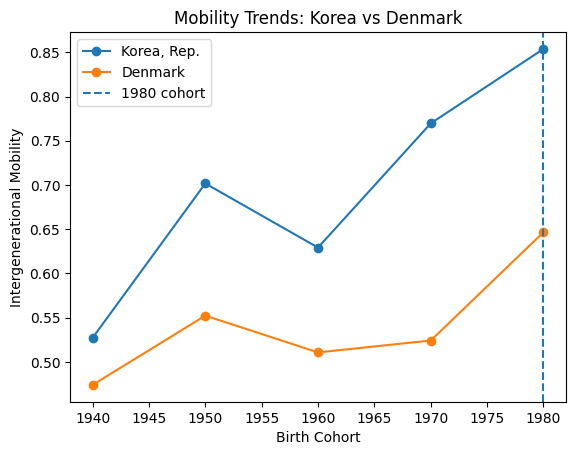

In [59]:
for country in [treat_country, control_country]:
    temp = pair_clean[pair_clean['country'] == country].sort_values('cohort')
    plt.plot(temp['cohort'], temp['mobility'], marker='o', label=country)

plt.axvline(x=1980, linestyle='--', label='1980 cohort')
plt.title('Mobility Trends: Korea vs Denmark')
plt.xlabel('Birth Cohort')
plt.ylabel('Intergenerational Mobility')
plt.legend()
plt.show()

In [60]:
korea_did = smf.ols(
    'mobility ~ treated + post + treated_post',
    data=pair_clean
).fit()

print(korea_did.summary())

                            OLS Regression Results                            
Dep. Variable:               mobility   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     5.898
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0320
Time:                        16:34:54   Log-Likelihood:                 14.011
No. Observations:                  10   AIC:                            -20.02
Df Residuals:                       6   BIC:                            -18.81
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.5152      0.038     13.390   

In [114]:
korea_denmark_result = pd.DataFrame({
    'Model': ['Korea vs Denmark DiD'],
    'DiD Coefficient': [round(korea_did.params['treated_post'], 4)],
    'P-value': [round(korea_did.pvalues['treated_post'], 4)],
    'Observations': [int(korea_did.nobs)]
})

korea_denmark_result

,Model,DiD Coefficient,P-value,Observations
0,Korea vs Denmark DiD,0.0656,0.6092,10


In [61]:
coef = korea_did.params['treated_post']
pval = korea_did.pvalues['treated_post']

print(f"DiD coefficient: {coef:.4f}")
print(f"P-value: {pval:.4f}")

if coef > 0:
    print("Korea's mobility increased more than Denmark's.")
else:
    print("Korea's mobility did not increase more than Denmark's.")

if pval < 0.05:
    print("This result is statistically significant.")
else:
    print("This result is not statistically significant.")

DiD coefficient: 0.0656
P-value: 0.6092
Korea's mobility increased more than Denmark's.
This result is not statistically significant.


In [62]:
possible_controls = [
    'Denmark',
    'Netherlands',
    'Sweden',
    'Canada',
    'France',
    'New Zealand',
    'Mexico',
    'Costa Rica',
    'Portugal',
    'Chile'
]

available_controls = gdim[
    gdim['country'].isin(possible_controls)
]['country'].unique()

available_controls

<StringArray>
[     'Canada',       'Chile',  'Costa Rica',     'Denmark',      'France',
      'Mexico', 'Netherlands', 'New Zealand',    'Portugal',      'Sweden']
Length: 10, dtype: str

In [63]:
treat_country = 'Korea, Rep.'
control_country = 'Mexico'

In [64]:
pair = gdim[
    gdim['country'].isin([treat_country, control_country])
].copy()

pair['correlation'] = pair['tm44']
pair['mobility'] = 1 - pair['correlation']

pair_clean = pair.groupby(['country', 'cohort'], as_index=False)['mobility'].mean()

pair_clean.sort_values(['country', 'cohort'])

,country,cohort,mobility
0,"Korea, Rep.",1940.0,0.527052
1,"Korea, Rep.",1950.0,0.701683
2,"Korea, Rep.",1960.0,0.629161
3,"Korea, Rep.",1970.0,0.769661
4,"Korea, Rep.",1980.0,0.853875
5,Mexico,1940.0,0.944530
6,Mexico,1950.0,0.663292
7,Mexico,1960.0,0.873747
8,Mexico,1970.0,0.724196
9,Mexico,1980.0,0.755257


In [22]:
pair_clean['treated'] = (pair_clean['country'] == treat_country).astype(int)

pair_clean['post'] = (pair_clean['cohort'] == 1980).astype(int)

pair_clean['treated_post'] = pair_clean['treated'] * pair_clean['post']

pair_clean.sort_values(['country', 'cohort'])

,country,cohort,mobility,treated,post,treated_post
0,"Korea, Rep.",1940.0,0.527052,1,0,0
1,"Korea, Rep.",1950.0,0.701683,1,0,0
2,"Korea, Rep.",1960.0,0.629161,1,0,0
3,"Korea, Rep.",1970.0,0.769661,1,0,0
4,"Korea, Rep.",1980.0,0.853875,1,1,1
5,Mexico,1940.0,0.944530,0,0,0
6,Mexico,1950.0,0.663292,0,0,0
7,Mexico,1960.0,0.873747,0,0,0
8,Mexico,1970.0,0.724196,0,0,0
9,Mexico,1980.0,0.755257,0,1,0


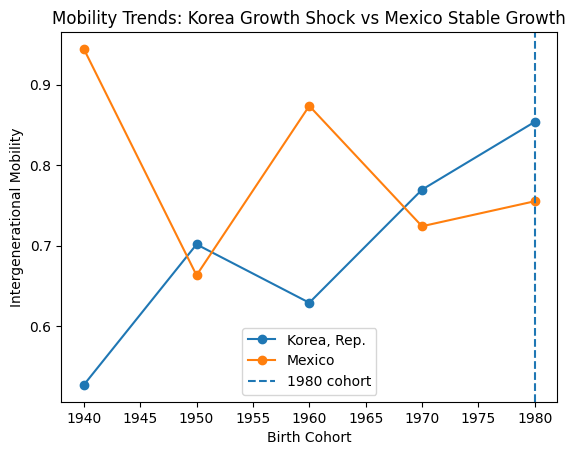

In [65]:
for country in [treat_country, control_country]:
    temp = pair_clean[pair_clean['country'] == country].sort_values('cohort')
    plt.plot(temp['cohort'], temp['mobility'], marker='o', label=country)

plt.axvline(x=1980, linestyle='--', label='1980 cohort')
plt.title('Mobility Trends: Korea Growth Shock vs Mexico Stable Growth')
plt.xlabel('Birth Cohort')
plt.ylabel('Intergenerational Mobility')
plt.legend()
plt.show()

In [23]:
korea_mexico_did = smf.ols(
    'mobility ~ treated + post + treated_post',
    data=pair_clean
).fit()

print(korea_mexico_did.summary())

                            OLS Regression Results                            
Dep. Variable:               mobility   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     1.342
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.346
Time:                        16:29:13   Log-Likelihood:                 9.7618
No. Observations:                  10   AIC:                            -11.52
Df Residuals:                       6   BIC:                            -10.31
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.8014      0.059     13.620   

In [113]:
korea_mexico_result = pd.DataFrame({
    'Model': ['Korea vs Mexico DiD'],
    'DiD Coefficient': [round(korea_mexico_did.params['treated_post'], 4)],
    'P-value': [round(korea_mexico_did.pvalues['treated_post'], 4)],
    'Observations': [int(korea_mexico_did.nobs)]
})

korea_mexico_result

,Model,DiD Coefficient,P-value,Observations
0,Korea vs Mexico DiD,0.2432,0.2391,10


In [66]:
coef = korea_mexico_did.params['treated_post']
pval = korea_mexico_did.pvalues['treated_post']

print(f"DiD coefficient: {coef:.4f}")
print(f"P-value: {pval:.4f}")

if coef > 0:
    print("Korea's mobility increased more than Mexico's.")
else:
    print("Korea's mobility did not increase more than Mexico's.")

if pval < 0.05:
    print("The result is statistically significant.")
else:
    print("The result is not statistically significant.")

DiD coefficient: 0.2432
P-value: 0.2391
Korea's mobility increased more than Mexico's.
The result is not statistically significant.


In [67]:
treat_country = 'Korea, Rep.'
control_country = 'Canada'

pair = gdim[
    gdim['country'].isin([treat_country, control_country])
].copy()

pair['correlation'] = pair['tm44']
pair['mobility'] = 1 - pair['correlation']

pair_clean = pair.groupby(['country', 'cohort'], as_index=False)['mobility'].mean()

pair_clean.sort_values(['country', 'cohort'])


,country,cohort,mobility
0,Canada,1940.0,0.670138
1,Canada,1950.0,0.695673
2,Canada,1960.0,0.690855
3,Canada,1970.0,0.724657
4,Canada,1980.0,0.701940
5,"Korea, Rep.",1940.0,0.527052
6,"Korea, Rep.",1950.0,0.701683
7,"Korea, Rep.",1960.0,0.629161
8,"Korea, Rep.",1970.0,0.769661
9,"Korea, Rep.",1980.0,0.853875


In [68]:
pair_clean['treated'] = (pair_clean['country'] == treat_country).astype(int)

pair_clean['post'] = (pair_clean['cohort'] == 1980).astype(int)

pair_clean['treated_post'] = pair_clean['treated'] * pair_clean['post']

pair_clean.sort_values(['country', 'cohort'])

,country,cohort,mobility,treated,post,treated_post
0,Canada,1940.0,0.670138,0,0,0
1,Canada,1950.0,0.695673,0,0,0
2,Canada,1960.0,0.690855,0,0,0
3,Canada,1970.0,0.724657,0,0,0
4,Canada,1980.0,0.701940,0,1,0
5,"Korea, Rep.",1940.0,0.527052,1,0,0
6,"Korea, Rep.",1950.0,0.701683,1,0,0
7,"Korea, Rep.",1960.0,0.629161,1,0,0
8,"Korea, Rep.",1970.0,0.769661,1,0,0
9,"Korea, Rep.",1980.0,0.853875,1,1,1


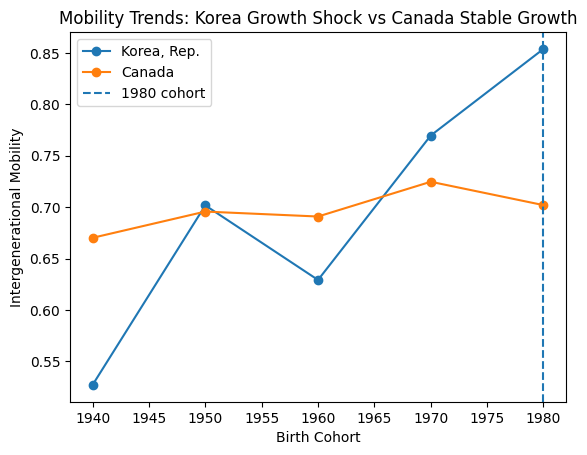

In [40]:
import matplotlib.pyplot as plt

for country in [treat_country, control_country]:
    temp = pair_clean[pair_clean['country'] == country].sort_values('cohort')
    plt.plot(temp['cohort'], temp['mobility'], marker='o', label=country)

plt.axvline(x=1980, linestyle='--', label='1980 cohort')
plt.title('Mobility Trends: Korea Growth Shock vs Canada Stable Growth')
plt.xlabel('Birth Cohort')
plt.ylabel('Intergenerational Mobility')
plt.legend()
plt.show()

In [69]:
korea_canada_did = smf.ols(
    'mobility ~ treated + post + treated_post',
    data=pair_clean
).fit()

In [70]:
coef = korea_canada_did.params['treated_post']
pval = korea_canada_did.pvalues['treated_post']

print(f"DiD coefficient: {coef:.4f}")
print(f"P-value: {pval:.4f}")

if coef > 0:
    print("Korea's mobility increased more than Canada's.")
else:
    print("Korea's mobility did not increase more than Canada's.")

if pval < 0.05:
    print("The result is statistically significant.")
else:
    print("The result is not statistically significant.")

DiD coefficient: 0.1904
P-value: 0.1601
Korea's mobility increased more than Canada's.
The result is not statistically significant.


In [112]:
did_result = pd.DataFrame({
    'Model': ['Korea vs Canada DiD'],
    'DiD Coefficient': [round(korea_did.params['treated_post'], 4)],
    'P-value': [round(korea_did.pvalues['treated_post'], 4)],
    'Observations': [int(korea_did.nobs)]
})

did_result

,Model,DiD Coefficient,P-value,Observations
0,Korea vs Canada DiD,0.0656,0.6092,10


In [71]:
len(pair_clean)

10

In [72]:
treat_country = 'Korea, Rep.'
control_country = 'Mexico'

pair_mexico = gdim[
    gdim['country'].isin([treat_country, control_country])
].copy()

pair_mexico['correlation'] = pair_mexico['tm44']
pair_mexico['mobility'] = 1 - pair_mexico['correlation']

pair_mexico_clean = pair_mexico.groupby(['country', 'cohort'], as_index=False)['mobility'].mean()

pair_mexico_clean.shape

(10, 3)

In [73]:
treat_country = 'Korea, Rep.'
control_country = 'Mexico'

pair_mexico = gdim[
    gdim['country'].isin([treat_country, control_country])
].copy()

pair_mexico['correlation'] = pair_mexico['tm44']
pair_mexico['mobility'] = 1 - pair_mexico['correlation']

pair_mexico_clean = pair_mexico.groupby(['country', 'cohort'], as_index=False)['mobility'].mean()

pair_mexico_clean.shape

(10, 3)

In [74]:
shock_1970 = shock_results[shock_results['shock_year'] == 1970].copy()

shock_1970 = shock_1970.dropna(subset=['growth_shock'])

shock_cutoff = shock_1970['growth_shock'].quantile(0.75)

stable_cutoff = shock_1970['growth_shock'].abs().quantile(0.25)

shock_1970['shock_treated'] = (shock_1970['growth_shock'] >= shock_cutoff).astype(int)
shock_1970['stable_control'] = (shock_1970['growth_shock'].abs() <= stable_cutoff).astype(int)

shock_1970[['Country Name', 'Country Code', 'growth_before', 'growth_after', 'growth_shock', 'shock_treated', 'stable_control']].sort_values(
    'growth_shock',
    ascending=False
).head(20)

,Country Name,Country Code,growth_before,growth_after,growth_shock,shock_treated,stable_control
33,Botswana,BWA,99.429089,414.270478,314.841389,1,0
126,"Korea, Rep.",KOR,92.829398,383.375981,290.546583,1,0
40,China,CHN,19.044944,219.205004,200.160060,1,0
97,Honduras,HND,-11.813998,149.902414,161.716413,1,0
61,East Asia & Pacific (excluding high income),EAP,23.563573,166.728832,143.165259,1,0
230,East Asia & Pacific (IDA & IBRD countries),TEA,23.626958,166.433354,142.806396,1,0
113,Iraq,IRQ,30.205994,171.409168,141.203173,1,0
208,Singapore,SGP,93.723389,232.600230,138.876841,1,0
167,Mauritius,MUS,9.340973,147.836864,138.495892,1,0
106,Indonesia,IDN,11.696707,120.312851,108.616144,1,0


In [75]:
shock_groups = shock_1970[
    (shock_1970['shock_treated'] == 1) | 
    (shock_1970['stable_control'] == 1)
].copy()

shock_groups['treated'] = shock_groups['shock_treated']

shock_groups[['Country Name', 'Country Code', 'growth_shock', 'treated']].head()

,Country Name,Country Code,growth_shock,treated
13,Australia,AUS,2.667907,0
16,Burundi,BDI,2.611601,0
17,Belgium,BEL,11.721115,0
18,Benin,BEN,-5.858693,0
19,Burkina Faso,BFA,6.309060,0


In [76]:
multi_did = gdim.merge(
    shock_groups[['Country Code', 'treated', 'growth_shock']],
    left_on='code',
    right_on='Country Code',
    how='inner'
)

multi_did.head()

,country,code,region,region_noHICgroup,incgroup2,incgroup3,incgroup4,fragile,survey,year,...,tm44,tm45,tm51,tm52,tm53,tm54,tm55,Country Code,treated,growth_shock
0,Australia,AUS,High-income economies,East Asia & Pacific,High-income economies,High income,High income,No,HILDA,2015.0,...,0.312581,0.415746,0.000000,0.017520,0.044224,0.219944,0.718312,AUS,0,2.667907
1,Australia,AUS,High-income economies,East Asia & Pacific,High-income economies,High income,High income,No,HILDA,2015.0,...,0.247118,0.393200,0.000000,0.020618,0.068351,0.151497,0.759534,AUS,0,2.667907
2,Australia,AUS,High-income economies,East Asia & Pacific,High-income economies,High income,High income,No,HILDA,2015.0,...,0.396417,0.444619,0.000000,0.014332,0.019400,0.290369,0.675898,AUS,0,2.667907
3,Australia,AUS,High-income economies,East Asia & Pacific,High-income economies,High income,High income,No,HILDA,2015.0,...,0.357500,0.481843,0.001549,0.052171,0.159365,0.284996,0.501918,AUS,0,2.667907
4,Australia,AUS,High-income economies,East Asia & Pacific,High-income economies,High income,High income,No,HILDA,2015.0,...,0.334893,0.492225,0.000000,0.079203,0.209592,0.206767,0.504437,AUS,0,2.667907


In [77]:
multi_did['correlation'] = multi_did['tm44']
multi_did['mobility'] = 1 - multi_did['correlation']

multi_clean = multi_did.groupby(
    ['country', 'code', 'cohort', 'treated'],
    as_index=False
)['mobility'].mean()

multi_clean['post'] = (multi_clean['cohort'] == 1980).astype(int)

multi_clean['treated_post'] = multi_clean['treated'] * multi_clean['post']

multi_clean.head()

,country,code,cohort,treated,mobility,post,treated_post
0,Australia,AUS,1940.0,0,0.667919,0,0
1,Australia,AUS,1950.0,0,0.619184,0,0
2,Australia,AUS,1960.0,0,0.635622,0,0
3,Australia,AUS,1970.0,0,0.609199,0,0
4,Australia,AUS,1980.0,0,0.550254,1,0


In [78]:
multi_clean.shape

(204, 7)

In [79]:
multi_country_did = smf.ols(
    'mobility ~ treated + post + treated_post',
    data=multi_clean
).fit()

print(multi_country_did.summary())

                            OLS Regression Results                            
Dep. Variable:               mobility   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.838
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.142
Time:                        16:35:54   Log-Likelihood:                 92.201
No. Observations:                 204   AIC:                            -176.4
Df Residuals:                     200   BIC:                            -163.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.6313      0.018     34.447   

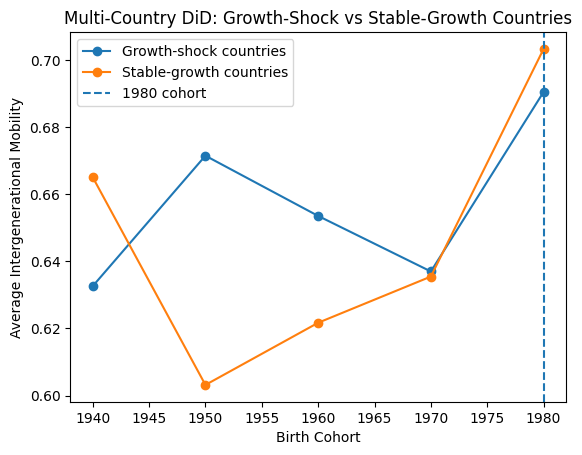

In [116]:
trend = multi_clean.groupby(['treated', 'cohort'], as_index=False)['mobility'].mean()

for group, label in [(1, 'Growth-shock countries'), (0, 'Stable-growth countries')]:
    temp = trend[trend['treated'] == group].sort_values('cohort')
    plt.plot(temp['cohort'], temp['mobility'], marker='o', label=label)

plt.axvline(x=1980, linestyle='--', label='1980 cohort')
plt.title('Multi-Country DiD: Growth-Shock vs Stable-Growth Countries')
plt.xlabel('Birth Cohort')
plt.ylabel('Average Intergenerational Mobility')
plt.legend()
plt.show()

In [115]:
mobility_data = gdim.copy()

mobility_data['correlation'] = mobility_data['tm44']

mobility_data['mobility'] = 1 - mobility_data['correlation']

mobility_clean = mobility_data.groupby(
    ['country', 'code', 'cohort'],
    as_index=False
)['mobility'].mean()

mobility_clean.head()

,country,code,cohort,mobility
0,Afghanistan,AFG,1980.0,0.673075
1,Albania,ALB,1940.0,0.629626
2,Albania,ALB,1950.0,0.587031
3,Albania,ALB,1960.0,0.524194
4,Albania,ALB,1970.0,0.591282


In [82]:
gdp_growth = gdp[['Country Name', 'Country Code', '1970', '1980']].copy()

gdp_growth = gdp_growth.dropna(subset=['1970', '1980'])

gdp_growth['growth_1970_1980'] = (
    (gdp_growth['1980'] - gdp_growth['1970']) / gdp_growth['1970']
) * 100

gdp_growth[['Country Name', 'Country Code', 'growth_1970_1980']].head()

,Country Name,Country Code,growth_1970_1980
1,Africa Eastern and Southern,AFE,2.998475
3,Africa Western and Central,AFW,16.341996
6,Andorra,AND,-20.285289
7,Arab World,ARB,65.431348
8,United Arab Emirates,ARE,140.194161


In [83]:
ols_data = mobility_clean.merge(
    gdp_growth[['Country Code', 'growth_1970_1980']],
    left_on='code',
    right_on='Country Code',
    how='inner'
)

ols_data.head()

,country,code,cohort,mobility,Country Code,growth_1970_1980
0,Argentina,ARG,1940.0,0.358823,ARG,11.160347
1,Argentina,ARG,1950.0,0.355217,ARG,11.160347
2,Argentina,ARG,1960.0,0.337465,ARG,11.160347
3,Argentina,ARG,1970.0,0.322635,ARG,11.160347
4,Argentina,ARG,1980.0,0.342976,ARG,11.160347


In [84]:
ols_data.shape

(413, 6)

In [85]:
simple_ols = smf.ols(
    'mobility ~ growth_1970_1980',
    data=ols_data
).fit()

print(simple_ols.summary())

                            OLS Regression Results                            
Dep. Variable:               mobility   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.3814
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.537
Time:                        16:36:09   Log-Likelihood:                 152.46
No. Observations:                 413   AIC:                            -300.9
Df Residuals:                     411   BIC:                            -292.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.6380      0.012  

In [92]:
simple_ols_result = pd.DataFrame({
    'Model': ['Simple OLS'],
    'Coefficient on Growth': [simple_ols.params['growth_1970_1980']],
    'P-value': [simple_ols.pvalues['growth_1970_1980']],
    'Observations': [int(simple_ols.nobs)]
})

simple_ols_result

,Model,Coefficient on Growth,P-value,Observations
0,Simple OLS,-0.000177,0.537187,413


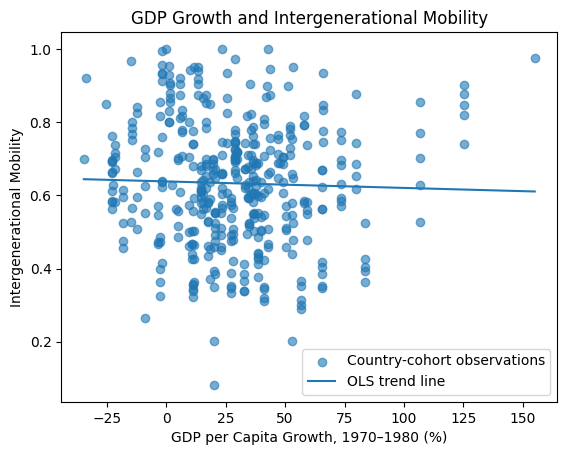

In [86]:
import matplotlib.pyplot as plt

# Sort data so the regression line draws smoothly
plot_data = ols_data.sort_values('growth_1970_1980').copy()

# Get predicted mobility from the OLS model
plot_data['predicted_mobility'] = simple_ols.predict(plot_data)

# Scatterplot
plt.scatter(
    plot_data['growth_1970_1980'],
    plot_data['mobility'],
    alpha=0.6,
    label='Country-cohort observations'
)

# OLS regression line
plt.plot(
    plot_data['growth_1970_1980'],
    plot_data['predicted_mobility'],
    label='OLS trend line'
)

plt.title('GDP Growth and Intergenerational Mobility')
plt.xlabel('GDP per Capita Growth, 1970–1980 (%)')
plt.ylabel('Intergenerational Mobility')
plt.legend()
plt.show()

In [87]:
coef = simple_ols.params['growth_1970_1980']
pval = simple_ols.pvalues['growth_1970_1980']

print(f"Growth coefficient: {coef:.4f}")
print(f"P-value: {pval:.4f}")

if coef > 0:
    print("Higher GDP growth is associated with higher mobility.")
else:
    print("Higher GDP growth is associated with lower mobility.")

if pval < 0.05:
    print("The relationship is statistically significant.")
else:
    print("The relationship is not statistically significant.")

Growth coefficient: -0.0002
P-value: 0.5372
Higher GDP growth is associated with lower mobility.
The relationship is not statistically significant.


In [88]:

gini = pd.read_csv('GINI copy.csv', skiprows=4)

gini.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,51.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
print("1980 Gini observations:", gini['1980'].notna().sum())
print("1990 Gini observations:", gini['1990'].notna().sum())
print("2000 Gini observations:", gini['2000'].notna().sum())

1980 Gini observations: 7
1990 Gini observations: 23
2000 Gini observations: 57


In [90]:
gini_clean = gini[['Country Code', '1990']].copy()

gini_clean = gini_clean.rename(columns={
    '1990': 'gini_1990'
})

gini_clean = gini_clean.dropna(subset=['gini_1990'])

gini_clean.head()

,Country Code,gini_1990
28,BOL,42.0
29,BRA,60.5
35,CAN,31.4
39,CHL,57.2
40,CHN,32.2


In [91]:
ols_gini_data = ols_data.merge(
    gini_clean[['Country Code', 'gini_1990']],
    on='Country Code',
    how='inner'
)

ols_gini_data.head()

,country,code,cohort,mobility,Country Code,growth_1970_1980,gini_1990
0,Bolivia,BOL,1940.0,0.685921,BOL,16.88199,42.0
1,Bolivia,BOL,1950.0,0.783342,BOL,16.88199,42.0
2,Bolivia,BOL,1960.0,0.680115,BOL,16.88199,42.0
3,Bolivia,BOL,1970.0,0.652146,BOL,16.88199,42.0
4,Bolivia,BOL,1980.0,0.700040,BOL,16.88199,42.0


In [92]:
ols_gini_data.shape

(97, 7)

In [93]:
fe_growth_gini = smf.ols(
    'mobility ~ growth_1970_1980 + gini_1990 + C(cohort)',
    data=ols_gini_data
).fit()

print(fe_growth_gini.summary())

                            OLS Regression Results                            
Dep. Variable:               mobility   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.9057
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.495
Time:                        16:36:34   Log-Likelihood:                 72.082
No. Observations:                  97   AIC:                            -130.2
Df Residuals:                      90   BIC:                            -112.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.6037    

In [117]:
growth_coef = fe_growth_gini.params['growth_1970_1980']
growth_pval = fe_growth_gini.pvalues['growth_1970_1980']

gini_coef = fe_growth_gini.params['gini_1990']
gini_pval = fe_growth_gini.pvalues['gini_1990']

print(f"GDP growth coefficient: {growth_coef:.4f}")
print(f"GDP growth p-value: {growth_pval:.4f}")

print(f"Gini coefficient: {gini_coef:.4f}")
print(f"Gini p-value: {gini_pval:.4f}")

GDP growth coefficient: -0.0007
GDP growth p-value: 0.2136
Gini coefficient: 0.0022
Gini p-value: 0.1144


In [94]:
fe_growth_gini_result = pd.DataFrame({
    'Variable': ['GDP Growth 1970–1980', 'Gini Inequality 1990'],
    'Coefficient': [
        fe_growth_gini.params['growth_1970_1980'],
        fe_growth_gini.params['gini_1990']
    ],
    'P-value': [
        fe_growth_gini.pvalues['growth_1970_1980'],
        fe_growth_gini.pvalues['gini_1990']
    ]
})

fe_growth_gini_result

,Variable,Coefficient,P-value
0,GDP Growth 1970–1980,-0.000715,0.213625
1,Gini Inequality 1990,0.002242,0.114364


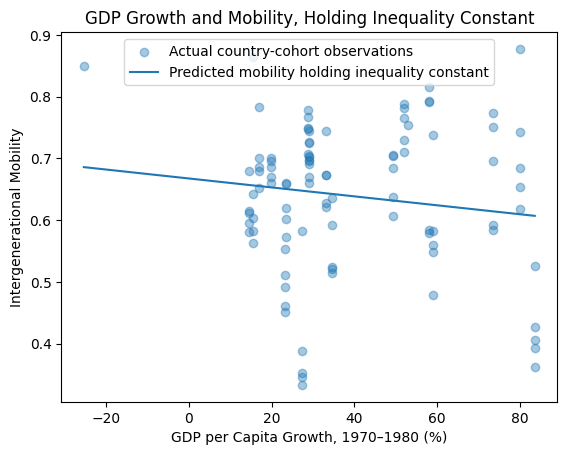

In [95]:
growth_gini_model = smf.ols(
    'mobility ~ growth_1970_1980 + gini_1990',
    data=ols_gini_data
).fit()

growth_range = pd.DataFrame({
    'growth_1970_1980': sorted(ols_gini_data['growth_1970_1980'])
})

average_gini = ols_gini_data['gini_1990'].mean()

growth_range['gini_1990'] = average_gini

growth_range['predicted_mobility'] = growth_gini_model.predict(growth_range)

plt.scatter(
    ols_gini_data['growth_1970_1980'],
    ols_gini_data['mobility'],
    alpha=0.4,
    label='Actual country-cohort observations'
)

plt.plot(
    growth_range['growth_1970_1980'],
    growth_range['predicted_mobility'],
    label='Predicted mobility holding inequality constant'
)

plt.title('GDP Growth and Mobility, Holding Inequality Constant')
plt.xlabel('GDP per Capita Growth, 1970–1980 (%)')
plt.ylabel('Intergenerational Mobility')
plt.legend()
plt.show()

In [96]:

secondary = pd.read_csv('Secondary_School-Enrollment copy.csv', skiprows=4)

secondary.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,137.829788,139.320587,135.124725,123.625908,131.802170,NaN,124.379367,NaN,NaN
1,Africa Eastern and Southern,AFE,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,43.254089,43.559410,44.128731,44.682560,45.150532,45.281620,45.155392,45.606079,NaN,NaN
2,Afghanistan,AFG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,55.536430,57.357849,NaN,NaN,NaN,NaN,59.613602,NaN,NaN,NaN
3,Africa Western and Central,AFW,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,42.433170,42.714561,43.906269,44.734341,45.567429,45.637299,46.442242,46.300491,NaN,NaN
4,Angola,AGO,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,53.135154,NaN,51.483905,NaN,NaN,NaN


In [97]:
print("1980 secondary enrollment observations:", secondary['1980'].notna().sum())
print("1990 secondary enrollment observations:", secondary['1990'].notna().sum())
print("2000 secondary enrollment observations:", secondary['2000'].notna().sum())
print("2010 secondary enrollment observations:", secondary['2010'].notna().sum())

1980 secondary enrollment observations: 131
1990 secondary enrollment observations: 123
2000 secondary enrollment observations: 159
2010 secondary enrollment observations: 195


In [98]:
secondary_clean = secondary[['Country Code', '1980']].copy()

secondary_clean = secondary_clean.rename(columns={
    '1980': 'secondary_1980'
})

secondary_clean = secondary_clean.dropna(subset=['secondary_1980'])

secondary_clean.head()

,Country Code,secondary_1980
1,AFE,20.370340
2,AFG,16.732780
3,AFW,15.000330
4,AGO,10.833940
5,ALB,87.463051


In [99]:
ols_secondary_data = ols_data.merge(
    secondary_clean[['Country Code', 'secondary_1980']],
    on='Country Code',
    how='inner'
)

ols_secondary_data.shape

(217, 7)

In [100]:
fe_growth_secondary = smf.ols(
    'mobility ~ growth_1970_1980 + secondary_1980 + C(cohort)',
    data=ols_secondary_data
).fit()

print(fe_growth_secondary.summary())

                            OLS Regression Results                            
Dep. Variable:               mobility   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     10.59
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           2.90e-10
Time:                        16:36:54   Log-Likelihood:                 89.866
No. Observations:                 217   AIC:                            -165.7
Df Residuals:                     210   BIC:                            -142.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.7327    

In [128]:
growth_coef = fe_growth_secondary.params['growth_1970_1980']
growth_pval = fe_growth_secondary.pvalues['growth_1970_1980']

secondary_coef = fe_growth_secondary.params['secondary_1980']
secondary_pval = fe_growth_secondary.pvalues['secondary_1980']

print(f"GDP growth coefficient: {growth_coef:.4f}")
print(f"GDP growth p-value: {growth_pval:.4f}")

print(f"Secondary enrollment coefficient: {secondary_coef:.4f}")
print(f"Secondary enrollment p-value: {secondary_pval:.4f}")

GDP growth coefficient: 0.0011
GDP growth p-value: 0.0016
Secondary enrollment coefficient: -0.0041
Secondary enrollment p-value: 0.0000


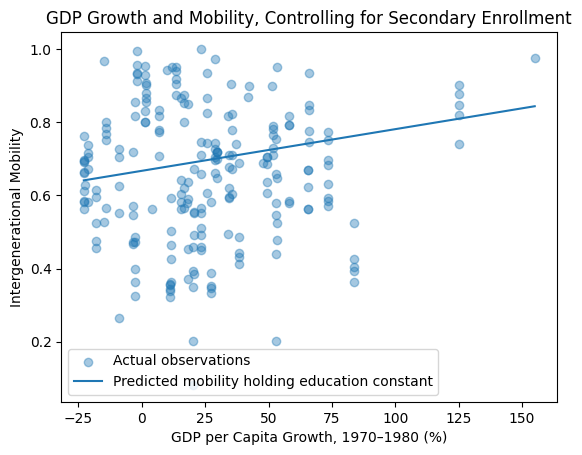

In [101]:
# Graph GDP growth and mobility while holding secondary enrollment constant

# Create a clean range of GDP growth values
growth_range = pd.DataFrame({
    'growth_1970_1980': sorted(ols_secondary_data['growth_1970_1980'])
})

# Hold secondary enrollment constant at the average level
average_secondary = ols_secondary_data['secondary_1980'].mean()
growth_range['secondary_1980'] = average_secondary

# Hold cohort fixed at 1980 for the prediction
growth_range['cohort'] = 1980

# Predict mobility using the fixed effects model
growth_range['predicted_mobility'] = fe_growth_secondary.predict(growth_range)

# Plot actual data points
plt.scatter(
    ols_secondary_data['growth_1970_1980'],
    ols_secondary_data['mobility'],
    alpha=0.4,
    label='Actual observations'
)

# Plot adjusted prediction line
plt.plot(
    growth_range['growth_1970_1980'],
    growth_range['predicted_mobility'],
    label='Predicted mobility holding education constant'
)

plt.title('GDP Growth and Mobility, Controlling for Secondary Enrollment')
plt.xlabel('GDP per Capita Growth, 1970–1980 (%)')
plt.ylabel('Intergenerational Mobility')
plt.legend()
plt.show()

In [102]:
ols_full_data = ols_data.merge(
    gini_clean[['Country Code', 'gini_1990']],
    on='Country Code',
    how='inner'
)

ols_full_data = ols_full_data.merge(
    secondary_clean[['Country Code', 'secondary_1980']],
    on='Country Code',
    how='inner'
)

ols_full_data.shape

(46, 8)

In [103]:
full_control_model = smf.ols(
    'mobility ~ growth_1970_1980 + gini_1990 + secondary_1980 + C(cohort)',
    data=ols_full_data
).fit()

print(full_control_model.summary())

                            OLS Regression Results                            
Dep. Variable:               mobility   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     1.304
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.275
Time:                        16:37:04   Log-Likelihood:                 28.480
No. Observations:                  46   AIC:                            -40.96
Df Residuals:                      38   BIC:                            -26.33
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.7082    

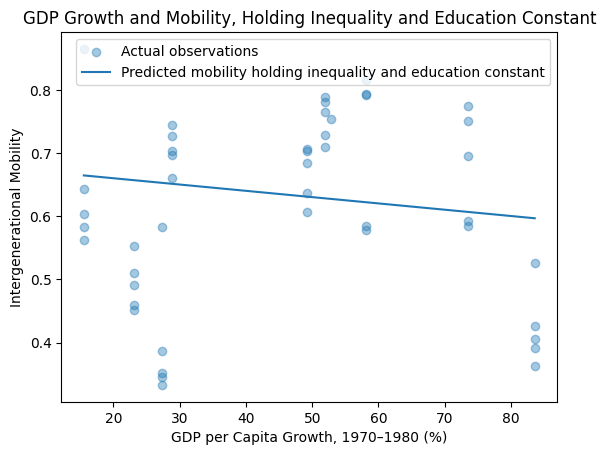

In [120]:
# Create a clean range of GDP growth values
growth_range = pd.DataFrame({
    'growth_1970_1980': sorted(ols_full_data['growth_1970_1980'])
})

# Hold inequality constant at the average Gini level
growth_range['gini_1990'] = ols_full_data['gini_1990'].mean()

# Hold secondary enrollment constant at the average level
growth_range['secondary_1980'] = ols_full_data['secondary_1980'].mean()

# Hold cohort fixed at 1980
growth_range['cohort'] = 1980

# Predict mobility from the full model
growth_range['predicted_mobility'] = full_control_model.predict(growth_range)

# Plot actual observations
plt.scatter(
    ols_full_data['growth_1970_1980'],
    ols_full_data['mobility'],
    alpha=0.4,
    label='Actual observations'
)

# Plot predicted line
plt.plot(
    growth_range['growth_1970_1980'],
    growth_range['predicted_mobility'],
    label='Predicted mobility holding inequality and education constant'
)

plt.title('GDP Growth and Mobility, Holding Inequality and Education Constant')
plt.xlabel('GDP per Capita Growth, 1970–1980 (%)')
plt.ylabel('Intergenerational Mobility')
plt.legend()
plt.show()

In [125]:
import statsmodels.formula.api as smf

fe_model = smf.ols(
    "mobility ~ growth_1970_1980 + C(country) + C(cohort)",
    data=ols_data
).fit()

print(fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:               mobility   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     10.96
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           5.39e-61
Time:                        13:41:17   Log-Likelihood:                 478.07
No. Observations:                 413   AIC:                            -740.1
Df Residuals:                     305   BIC:                            -305.6
Df Model:                         107                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [126]:
fe_result = pd.DataFrame({
    "Model": ["Country and Cohort Fixed Effects"],
    "Coefficient on Growth": [fe_model.params.get("growth_1970_1980")],
    "P-value": [fe_model.pvalues.get("growth_1970_1980")],
    "Observations": [int(fe_model.nobs)]
})

fe_result

,Model,Coefficient on Growth,P-value,Observations
0,Country and Cohort Fixed Effects,0.004059,2.204749e-13,413


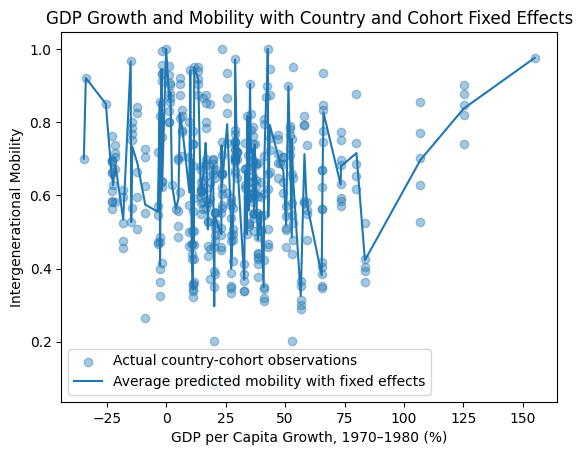

In [128]:
import matplotlib.pyplot as plt

plot_fe = ols_data.copy()
plot_fe["predicted_mobility_fe"] = fe_model.predict(plot_fe)

fe_line = plot_fe.groupby("growth_1970_1980", as_index=False)["predicted_mobility_fe"].mean()
fe_line = fe_line.sort_values("growth_1970_1980")

plt.scatter(
    plot_fe["growth_1970_1980"],
    plot_fe["mobility"],
    alpha=0.4,
    label="Actual country-cohort observations"
)

plt.plot(
    fe_line["growth_1970_1980"],
    fe_line["predicted_mobility_fe"],
    label="Average predicted mobility with fixed effects"
)

plt.title("GDP Growth and Mobility with Country and Cohort Fixed Effects")
plt.xlabel("GDP per Capita Growth, 1970–1980 (%)")
plt.ylabel("Intergenerational Mobility")
plt.legend()
plt.show()